# Predicting a Continuous Target with Regression (Titanic)

**Name:** Sabriya Sowers  
**Date:** November 12, 2025

## Introduction
This analysis uses the Titanic passenger dataset to develop predictive models for estimating **fare**, a continuous financial variable representing the amount paid for passage. The dataset includes a wide range of demographic and travel-related attributes—such as passenger class, age, sex, and ticket characteristics—that may influence fare levels.


# **Section 1: Import and Inspect the Data**

In [594]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load Titanic dataset from seaborn and verify
titanic = sns.load_dataset("titanic")

# Display first 10 rows
print(titanic.head(10))

# Check for missing values
titanic.isnull().sum()

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# **Section 2: Data Exploration and Preparation**

In [595]:
# Handle missing values in age using the median
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

# Remove rows with missing fare values (our target variable)
titanic = titanic.dropna(subset=['fare'])

# Create a new engineered feature: family size (passenger + relatives aboard)
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# **Section 3: Feature Selection and Justification**

In [596]:
# Case 1. age
X1 = titanic[['age']]
y1 = titanic['fare']

In [597]:
# Case 2. family_size
X2 = titanic[['family_size']]
y2 = titanic['fare']

In [598]:
# Case 3. age, family_size
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

In [599]:
# Case 4. pclass, age, family_size (all numeric)
X4 = titanic[['pclass', 'age', 'family_size']]
y4 = titanic['fare']

3.1 Histograms (distribution of numeric features)

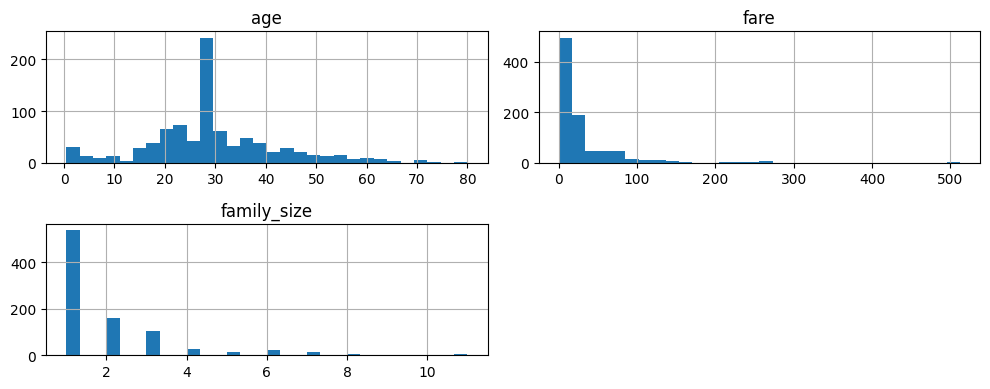

In [600]:
titanic[['age', 'fare', 'family_size']].hist(bins=30, figsize=(10,4))
plt.tight_layout()
plt.show()

3.2 Boxplots (detect outliers)

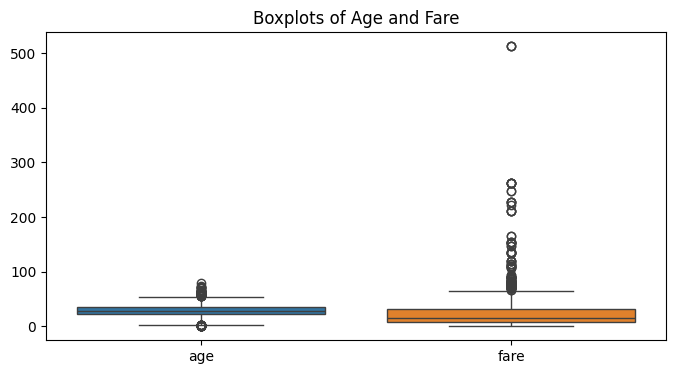

In [601]:
plt.figure(figsize=(8,4))
sns.boxplot(data=titanic[['age', 'fare']])
plt.title("Boxplots of Age and Fare")
plt.show()

3.3 Countplots (categorical features)

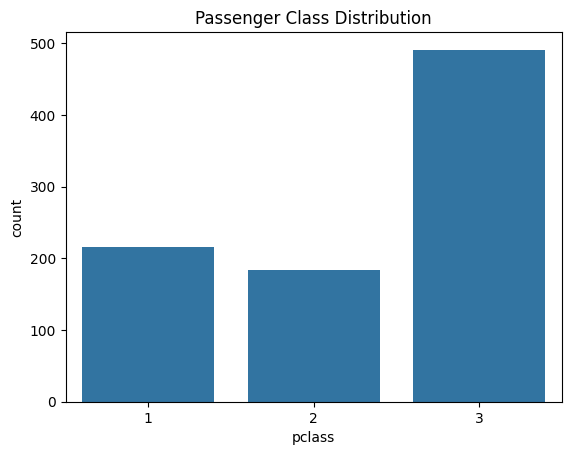

In [602]:
sns.countplot(x='pclass', data=titanic)
plt.title("Passenger Class Distribution")
plt.show()

3.4 Scatterplots (relationships with the target)

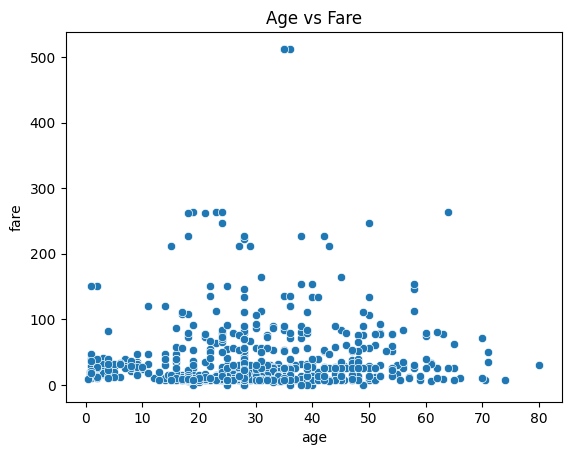

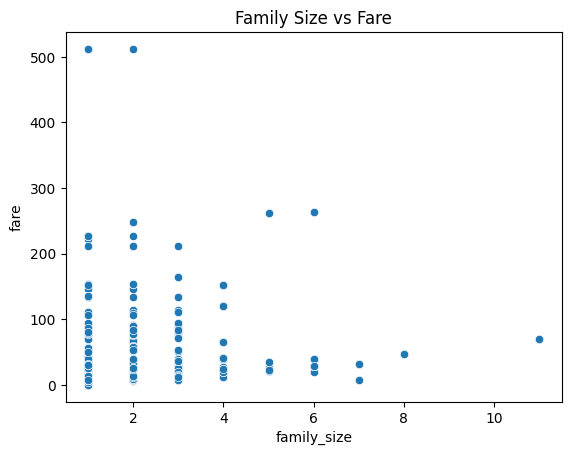

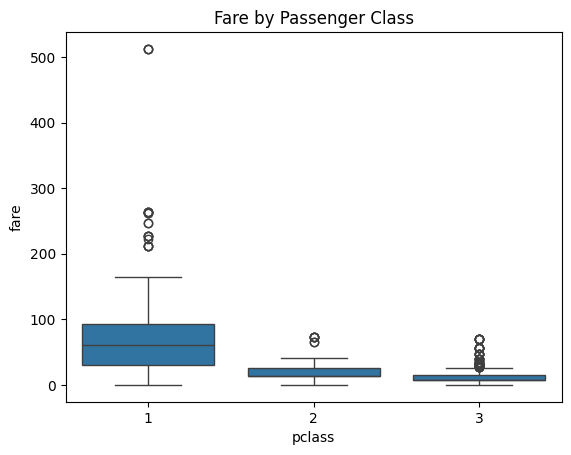

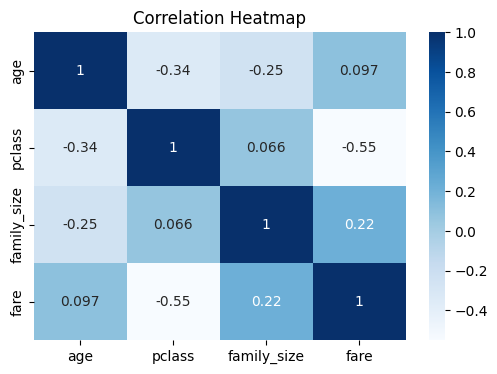

In [603]:
# Age vs Fare
sns.scatterplot(x='age', y='fare', data=titanic)
plt.title("Age vs Fare")
plt.show()

# Family Size vs Fare
sns.scatterplot(x='family_size', y='fare', data=titanic)
plt.title("Family Size vs Fare")
plt.show()

# Passenger Class vs Fare
sns.boxplot(x='pclass', y='fare', data=titanic)
plt.title("Fare by Passenger Class")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(titanic[['age','pclass','family_size','fare']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

**Reflection 1:**

**Visual Insights**
- **Age vs Fare:** There is no strong linear relationship between age and fare. Fares vary widely at all ages, suggesting age alone is not a strong predictor.
- **Family Size vs Fare:** Smaller families (around 1–3 people) show higher variability in fares, including the highest. Larger family sizes tend to have lower fares, possibly due to group accommodations or lower-class cabins.
- **Correlation Heatmap:** Passenger class has the strongest negative correlation with fare (–0.55) confirming that higher classes paid more. Age has almost no correlation with fare, while family size shows a weak positive relationship.
- **Fare by Passenger Class:** This boxplot shows a clear separation among classes. First-class passengers paid significantly more on average, with more high-fare outliers. Second and third class fares are much lower and tightly grouped. This reinforces that `pclass` is a key predictor in regression models.

**Why might these features affect a passenger’s fare?**
- **Age:** Fare pricing may differ for adults and children.  
- **Family size:** Larger families may share cabins or qualify for group pricing, which can influence fare.  
- **Passenger class (pclass):** This is one of the strongest predictors of fare because higher classes paid significantly more for premium accommodations.

**List all available features**
- survived  
- pclass  
- sex  
- age  
- sibsp  
- parch  
- ticket  
- fare  
- cabin  
- embarked  
- family_size *(engineered)*  

**Which other features could improve predictions and why?**
- **sex:** Could capture differences in cabin assignment or class distribution.
- **embarked:** Fares varied by port of departure.
- **cabin:** Reflects accommodation quality which will vary.  
- **ticket:** Ticket groups or fare classes may relate to pricing patterns.

**How many variables are in your Case 4?**
Three variables

**Which variable(s) did you choose for Case 4 and why?**
I selected **pclass, age, and family_size**.  
- **pclass** is directly tied to ticket pricing.  
- **age** captures pricing differences between adults and children.  
- **family_size** reflects group travel behavior and shared accommodations.  
Together these features provide a stronger foundation for predicting fare than using a single variable.

# **Section 4: Train a Regression Model (Linear Regression)**

**4.1 Split the Data**

In [604]:
# Case 1
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)
# Case 2
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)
# Case 3
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=123)
# Case 4
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=123)

4.2 Train and Evaluate Linear Regression Models (all 4 cases)

In [605]:
lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)

# Predictions for cases 1-4
y_pred_train1 = lr_model1.predict(X1_train)
y_pred_test1 = lr_model1.predict(X1_test)

y_pred_train2 = lr_model2.predict(X2_train)
y_pred_test2 = lr_model2.predict(X2_test)

y_pred_train3 = lr_model3.predict(X3_train)
y_pred_test3 = lr_model3.predict(X3_test)

y_pred_train4 = lr_model4.predict(X4_train)
y_pred_test4 = lr_model4.predict(X4_test)

4.3 Report Performance

In [606]:
# Case 1
mse1 = mean_squared_error(y1_test, y_pred_test1)
rmse1 = np.sqrt(mse1)
print("Case 1: Training R²:", r2_score(y1_train, y_pred_train1))
print("Case 1: Test R²:", r2_score(y1_test, y_pred_test1))
print("Case 1: Test RMSE:", rmse1)
print("Case 1: Test MAE:", mean_absolute_error(y1_test, y_pred_test1))

# Case 2
mse2 = mean_squared_error(y2_test, y_pred_test2)
rmse2 = np.sqrt(mse2)
print("Case 2: Training R²:", r2_score(y2_train, y_pred_train2))
print("Case 2: Test R²:", r2_score(y2_test, y_pred_test2))
print("Case 2: Test RMSE:", rmse2)
print("Case 2: Test MAE:", mean_absolute_error(y2_test, y_pred_test2))

# Case 3
mse3 = mean_squared_error(y3_test, y_pred_test3)
rmse3 = np.sqrt(mse3)
print("Case 3: Training R²:", r2_score(y3_train, y_pred_train3))
print("Case 3: Test R²:", r2_score(y3_test, y_pred_test3))
print("Case 3: Test RMSE:", rmse3)
print("Case 3: Test MAE:", mean_absolute_error(y3_test, y_pred_test3))

# Case 4
mse4 = mean_squared_error(y4_test, y_pred_test4)
rmse4 = np.sqrt(mse4)
print("Case 4: Training R²:", r2_score(y4_train, y_pred_train4))
print("Case 4: Test R²:", r2_score(y4_test, y_pred_test4))
print("Case 4: Test RMSE:", rmse4)
print("Case 4: Test MAE:", mean_absolute_error(y4_test, y_pred_test4))

Case 1: Training R²: 0.009950688019452314
Case 1: Test R²: 0.0034163395508415295
Case 1: Test RMSE: 37.97164180172938
Case 1: Test MAE: 25.28637293162364
Case 2: Training R²: 0.049915792364760736
Case 2: Test R²: 0.022231186110131973
Case 2: Test RMSE: 37.6114940041967
Case 2: Test MAE: 25.02534815941641
Case 3: Training R²: 0.07347466201590014
Case 3: Test R²: 0.049784832763073106
Case 3: Test RMSE: 37.0777586646559
Case 3: Test MAE: 24.284935030470688
Case 4: Training R²: 0.36396753488910505
Case 4: Test R²: 0.3855521972173821
Case 4: Test RMSE: 29.815698763780848
Case 4: Test MAE: 20.16225215201267


**Reflection 2:**

**Compare Train vs Test Results for Each Case**
- Case 1 underfit. Both training R² (0.01) and test R² (0.00) are extremely low, showing that the model did not learn meaningful patterns. Age alone is not predictive of fare, so the model remains weak on both training and testing data.

- Case 2 underfit. Training R² (0.05) and test R² (0.02) are still very low. Family size does not have a strong linear relationship with fare and the model captures very little structure in the data.

- Case 3 underfit. Adding age + family_size improved performance slightly, but both train (0.07) and test (0.05) R² remain low. The model is too simple to capture the factors driving fare.

- Case 4 generalizes well and does not appear to overfit. Training R² is 0.36 and test R² is 0.39, which are very close. The model is strong enough to capture meaningful patterns, mainly because `pclass` is highly predictive.

**Did adding age improve the model?**
Only slightly. From Case 2 → Case 3, R² improved a bit and errors decreased. Age likely has *some* connection to fare (children vs adults), but not a strong or consistent one. The scatterplot showed wide variation in fares across all ages. The data does not support a strong linear relationship between age and fare.

**Worst Model**
Case 1 (Age only). It had the lowest R² (near zero) and the highest MAE and RMSE. The model could not explain any real variation in fare.

**Would more training data help?** 
Probably not. The issue is not the amount of data, but that **age is not predictive of fare**. Adding more data would not create a relationship that doesn’t exist.

**Best Model**
Case 4 (pclass, age, family_size).It had the highest training and test R² (~0.38), the lowest RMSE (~29.8), and the lowest MAE (~20). Adding `pclass` made the model much stronger.

**Would more training data help?**
Possibly. Because the model is capturing real structure (pclass → fare), more data might slightly improve performance. But the major gains already came from using a meaningful feature, not from sample size.

**Section 5: Compare Alternative Models (Ridge, Elastic Net, Polynomial Regression)**

### **Best Model Selection**
Based on the performance results, **Case 4 is the best-performing model**.  

**Why Case 4 is best:**
- It has the highest training R² (0.36) and highest test R² (0.39) of all cases.  
- It has the lowest RMSE (~29.82) and the lowest MAE (~20.16).  
- Train and test performance are close in value, indicating good generalization.  
- Including `pclass` captures a major, meaningful factor in ticket pricing that is not present in the other cases.

**Features in Case 4:**  
`pclass`, `age`, `family_size`

These features explain more variation in fare compared to Cases 1–3, making Case 4 the strongest candidate for further modeling.

5.1 Ridge Regression (L2 penalty)

In [607]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X1_train, y1_train)
y_pred_ridge = ridge_model.predict(X1_test)

5.2 Elastic Net (L1 + L2 combined)

In [608]:
elastic_model = ElasticNet(alpha=0.3, l1_ratio=0.5)
elastic_model.fit(X1_train, y1_train)
y_pred_elastic = elastic_model.predict(X1_test)

5.3 Polynomial Regression

In [609]:
# Set up the poly inputs
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X1_train)
X_test_poly = poly.transform(X1_test)

In [610]:
# Use the poly inputs in the LR model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y1_train)
y_pred_poly = poly_model.predict(X_test_poly)

5.4 Visualize Polynomial Cubic Fit (for 1 input feature)

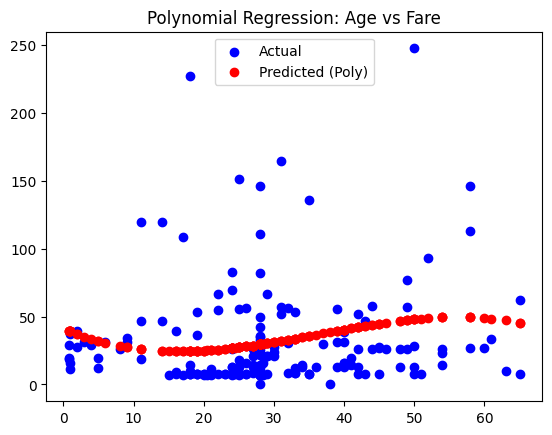

In [611]:
plt.scatter(X1_test, y1_test, color='blue', label='Actual')
plt.scatter(X1_test, y_pred_poly, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Regression: Age vs Fare")
plt.show()

**Reflections 3:**
**1. What patterns does the cubic model seem to capture?**  
The cubic model mainly captures a very small upward trend as age increases. It creates a smooth curve that slightly dips at younger ages and rises again for older ages, but overall it stays fairly flat. This makes sense because there is not a strong curved relationship between age and fare.

**2. Where does it perform well or poorly?**  
It performs best in the middle-age range (about ages 20–40), where most of the data points are clustered.  
It performs poorly at both age extremes — very young and very old passengers — because the model tries to create curve shapes even though there are fewer points there, so it becomes less accurate.

**3. Did the polynomial fit outperform linear regression?**  
No. The polynomial model did not outperform linear regression. Both models struggled because age alone does not explain fare. The polynomial curve looks smoother than the linear line, but it still misses the large variation in real fares, so accuracy does not improve.

**4. Where does it fit best (graphically or by types of points)?**  
It fits best around the lower-fare passengers in the middle-age range.  
It fits the worst for very high-fare cases (the outliers), because the polynomial model cannot “jump up” to match those extreme values.

5.4 Compare All Models

In [612]:
def report(name, y_true, y_pred):
    # R²
    print(f"{name} R²: {r2_score(y_true, y_pred):.3f}")
    
    # MSE then RMSE (no 'squared' keyword)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5          # or np.sqrt(mse)
    print(f"{name} RMSE: {rmse:.2f}")
    
    # MAE
    print(f"{name} MAE: {mean_absolute_error(y_true, y_pred):.2f}\n")

report("Linear",     y1_test, y_pred_test1)
report("Ridge",      y1_test, y_pred_ridge)
report("ElasticNet", y1_test, y_pred_elastic)
report("Polynomial", y1_test, y_pred_poly)

Linear R²: 0.003
Linear RMSE: 37.97
Linear MAE: 25.29

Ridge R²: 0.003
Ridge RMSE: 37.97
Ridge MAE: 25.29

ElasticNet R²: 0.003
ElasticNet RMSE: 37.97
ElasticNet MAE: 25.28

Polynomial R²: -0.003
Polynomial RMSE: 38.10
Polynomial MAE: 25.30



| Model       | R²      | RMSE   | MAE    |
|------------|---------|--------|--------|
| Linear     | 0.003   | 37.97  | 25.29  |
| Ridge      | 0.003   | 37.97  | 25.29  |
| ElasticNet | 0.003   | 37.97  | 25.28  |
| Polynomial | -0.003  | 38.10  | 25.30  |

5.5 Visualize Higher Order Polynomial (for the same 1 input case)

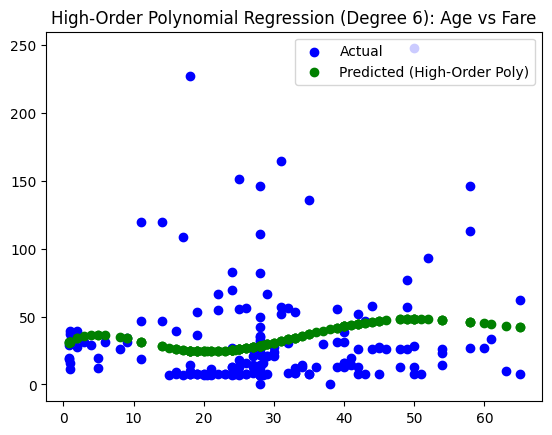

In [613]:
# Higher-order polynomial degree 6
poly_high = PolynomialFeatures(degree=6)
X_train_poly_high = poly_high.fit_transform(X1_train)
X_test_poly_high = poly_high.transform(X1_test)

# Fit linear regression to polynomial features
poly_high_model = LinearRegression()
poly_high_model.fit(X_train_poly_high, y1_train)

# Predictions
y_pred_poly_high = poly_high_model.predict(X_test_poly_high)

# Visualization
plt.scatter(X1_test, y1_test, color='blue', label='Actual')
plt.scatter(X1_test, y_pred_poly_high, color='green', label='Predicted (High-Order Poly)')
plt.legend()
plt.title("High-Order Polynomial Regression (Degree 6): Age vs Fare")
plt.show()

### **Reflection 4**
Both the cubic model (degree 3) and the higher-order model (degree 6) create a curved line through the data, but neither one matches the actual Fare values very well. This is mainly because Age and Fare don’t have a strong relationship in this dataset.

### **Cubic Polynomial (Degree 3)**
- Makes a smoother and more steady curve  
- Doesn’t bend too sharply  
- Shows the general trend without doing anything extreme  
- Feels more reasonable for this data

### **Higher-Order Polynomial (Degree 6)**
- The curve becomes much more “wiggly”  
- It reacts too much to small ups and downs in the data  
- Looks like it’s trying too hard to fit every little point  
- Doesn’t actually improve predictions

### **Conclusion**
The degree-3 model seems better because it keeps things simple and smooth. The degree-6 model is more complicated, but it doesn’t help and actually starts to overfit the noise. So the cubic polynomial works better for this situation.

# **Section 6: Final Thoughts & Insights**

# **Section 6: Final Thoughts & Insights**

### **6.1 Summary of Findings**
Predicting **fare** was harder than expected because the data has a lot of variation, but a few things did stand out:

- **Most useful feature:**  
  `pclass` was the strongest predictor. It showed the clearest relationship with fare and helped the model the most.

- **Best regression model:**  
  The **Case 4 linear regression model** (using `pclass`, `age`, and `family_size`) performed the best. It had the highest R² and the lowest error values.

- **Effect of complexity and regularization:**  
  Using more complex models like Ridge, ElasticNet, or higher-order polynomials did **not** improve the results.  
  Ridge and ElasticNet were basically the same as linear regression, and the polynomial models became more complicated without helping accuracy.  
  This shows that adding complexity does not fix weak feature-target relationships.

### **6.2 Challenges**
- **Was fare hard to predict?**  
  Yes. People of the same age or family size paid very different fares, so the relationship is not strong or clear. This made it difficult for the models to learn meaningful patterns.

- **Impact of skew and outliers:**  
  Fare has several extreme high-value outliers (very pricey tickets).  
  These outliers pulled the model off track and made predictions less accurate, especially for linear models that can’t adjust well for large jumps in values.

### **6.3 Optional Next Steps**
If I continued this project, I would explore:
- Adding more features such as `sex`, `embarked`, or encoded `cabin` or `ticket` details  
- Trying to predict a different variable instead of fare